In [1]:
import pandas as pd
import sys
import os
import jax
from arviz.labels import MapLabeller

sys.path.append(os.path.abspath(os.path.join('../..')))

from utils.modeling import (
    encode_categorical_covariates, 
    fit_model_and_extract_idata,
    hierarchical_ordered_logistic_model
    )

from utils.plotting import (
    plot_predictive_distributions,
    plot_model_comparison,
    plot_combined_figure
)

/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get data

In [2]:
df = pd.read_csv('data.csv')

# Check
print('Unique graders:', set(df['grader']))
print('Unique models:', set(df['LLM']))
df.head(5)

Unique graders: {'Human Z', 'Autograder C', 'Human Y', 'Autograder B', 'Autograder A', 'Human X'}
Unique models: {'LLM A', 'LLM B'}


,score,grader,LLM
0,8,Human X,LLM A
1,7,Human X,LLM A
2,5,Human X,LLM A
3,6,Human X,LLM A
4,8,Human X,LLM A


# Add column 'grader type' (human vs not human)

In [3]:
df['grader_type'] = df['grader'].apply(lambda x: 'human' if 'Human' in str(x) else 'model')
print(df.head(2))
print(df.tail(2))

   score   grader    LLM grader_type
0      8  Human X  LLM A       human
1      7  Human X  LLM A       human
      score        grader    LLM grader_type
1046      6  Autograder C  LLM B       model
1047      3  Autograder C  LLM B       model


# Fit model

In [4]:
# Define covariates and outcome
main_effects = ['grader', 'LLM', 'grader_type']
interactions = [('grader', 'LLM')]
outcome = 'score'  # ordinal variable, 0–10

# Encode categorical covariates
covariates_dict, category_maps = encode_categorical_covariates(df, main_effects)

# Encore the outcome
allowed_scores = list(range(11))  # ordinal values: 0–10
score_map = {val: i for i, val in enumerate(allowed_scores)}
y = df[outcome].map(score_map).values

# Fit models
rng_key = jax.random.PRNGKey(0)

## Model with no grader type
mcmc_no_graderType, idata_no_graderType = fit_model_and_extract_idata(
    rng_key, covariates_dict, y, 
    main_effects = ['grader', 'LLM'], 
    interactions=interactions, 
    category_maps=category_maps
)

## Hierachical model with grader type
mcmc_hierarchical, idata_hierarchical = fit_model_and_extract_idata(
    rng_key, 
    covariates_dict, # grader and grader_type for the hierarchical model come from this
    y, 
    main_effects=['LLM'],  # only non-hierarchical effects (no grader or grader_type)
    interactions=[('grader', 'LLM')], 
    category_maps=category_maps,
    model=hierarchical_ordered_logistic_model  
)


sample: 100%|██████████| 2000/2000 [00:46<00:00, 43.31it/s, 127 steps of size 2.96e-02. acc. prob=0.90]


# Compare models

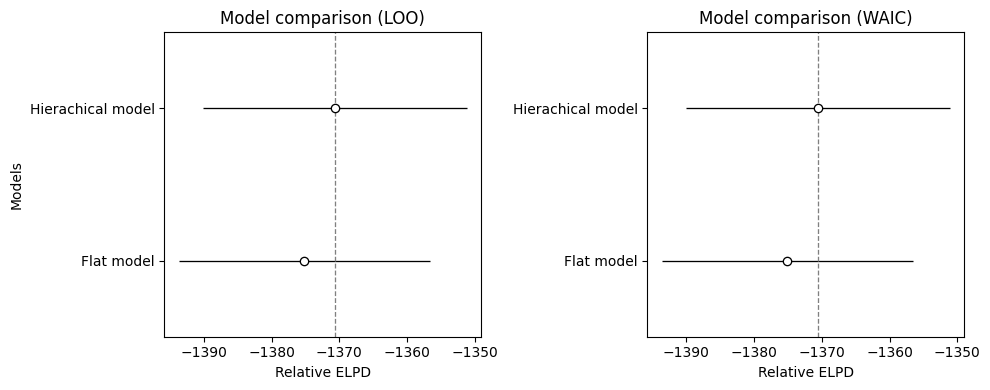

In [5]:
idata_dict = {
    "Flat model": idata_no_graderType,
    "Hierachical model": idata_hierarchical,
}

plot_model_comparison(idata_dict, ylabel="Models", fig_path="../../figures/figure4c.png")

# Fitted parameters

In [6]:
mcmc_no_graderType.print_summary()


                                  mean       std    median      5.0%     95.0%     n_eff     r_hat
                    b_LLM[0]      1.81      0.30      1.82      1.32      2.27    753.02      1.00
                 b_grader[0]     -2.62      0.57     -2.58     -3.52     -1.69    948.44      1.00
                 b_grader[1]     -2.71      0.53     -2.71     -3.58     -1.84    928.39      1.00
                 b_grader[2]     -0.63      0.50     -0.64     -1.43      0.20    926.59      1.00
                 b_grader[3]      0.66      0.54      0.63     -0.20      1.57    970.95      1.00
                 b_grader[4]      1.65      0.56      1.65      0.79      2.65   1030.15      1.00
 b_interaction_grader_LLM[0]      0.10      0.72      0.08     -1.03      1.31    925.53      1.00
 b_interaction_grader_LLM[1]     -1.42      0.67     -1.43     -2.44     -0.30   1017.97      1.00
 b_interaction_grader_LLM[2]     -1.12      0.66     -1.10     -2.23     -0.09    954.23      1.00
 b_intera

In [7]:
mcmc_hierarchical.print_summary()


                           mean       std    median      5.0%     95.0%     n_eff     r_hat
             b_LLM[0]      1.85      0.30      1.85      1.37      2.34    341.04      1.00
    b_grader_LLM[0,0]      0.67      0.75      0.62     -0.45      1.93    594.90      1.00
    b_grader_LLM[0,1]     -1.06      0.75     -1.07     -2.29      0.12    539.87      1.00
    b_grader_LLM[1,0]     -0.58      0.75     -0.58     -1.68      0.67    476.47      1.00
    b_grader_LLM[1,1]      0.07      0.68      0.03     -1.10      1.09    744.84      1.00
    b_grader_LLM[2,0]      0.53      0.83      0.53     -0.84      1.85    450.16      1.00
    b_grader_LLM[2,1]      0.44      0.87      0.42     -0.94      1.81    246.35      1.01
    b_grader_LLM[3,0]     -0.39      0.82     -0.41     -1.84      0.86    255.58      1.00
    b_grader_LLM[3,1]     -0.33      0.78     -0.32     -1.66      0.88    286.41      1.00
    b_grader_LLM[4,0]      0.39      0.69      0.42     -0.92      1.35    461.

## Checks

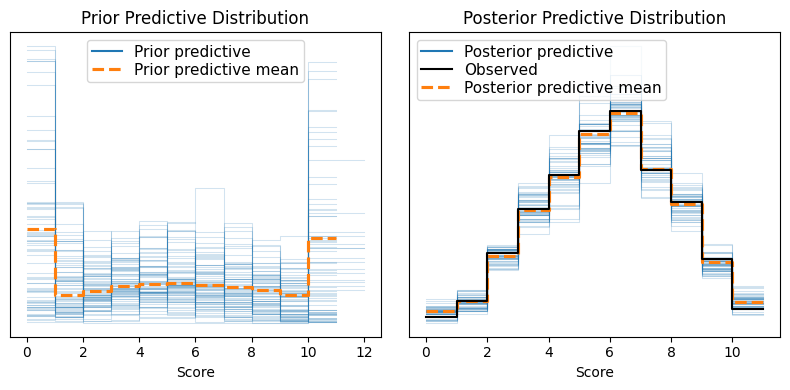

In [8]:
plot_predictive_distributions(idata_hierarchical, fig_path="fig_predictive.png")

# Figure

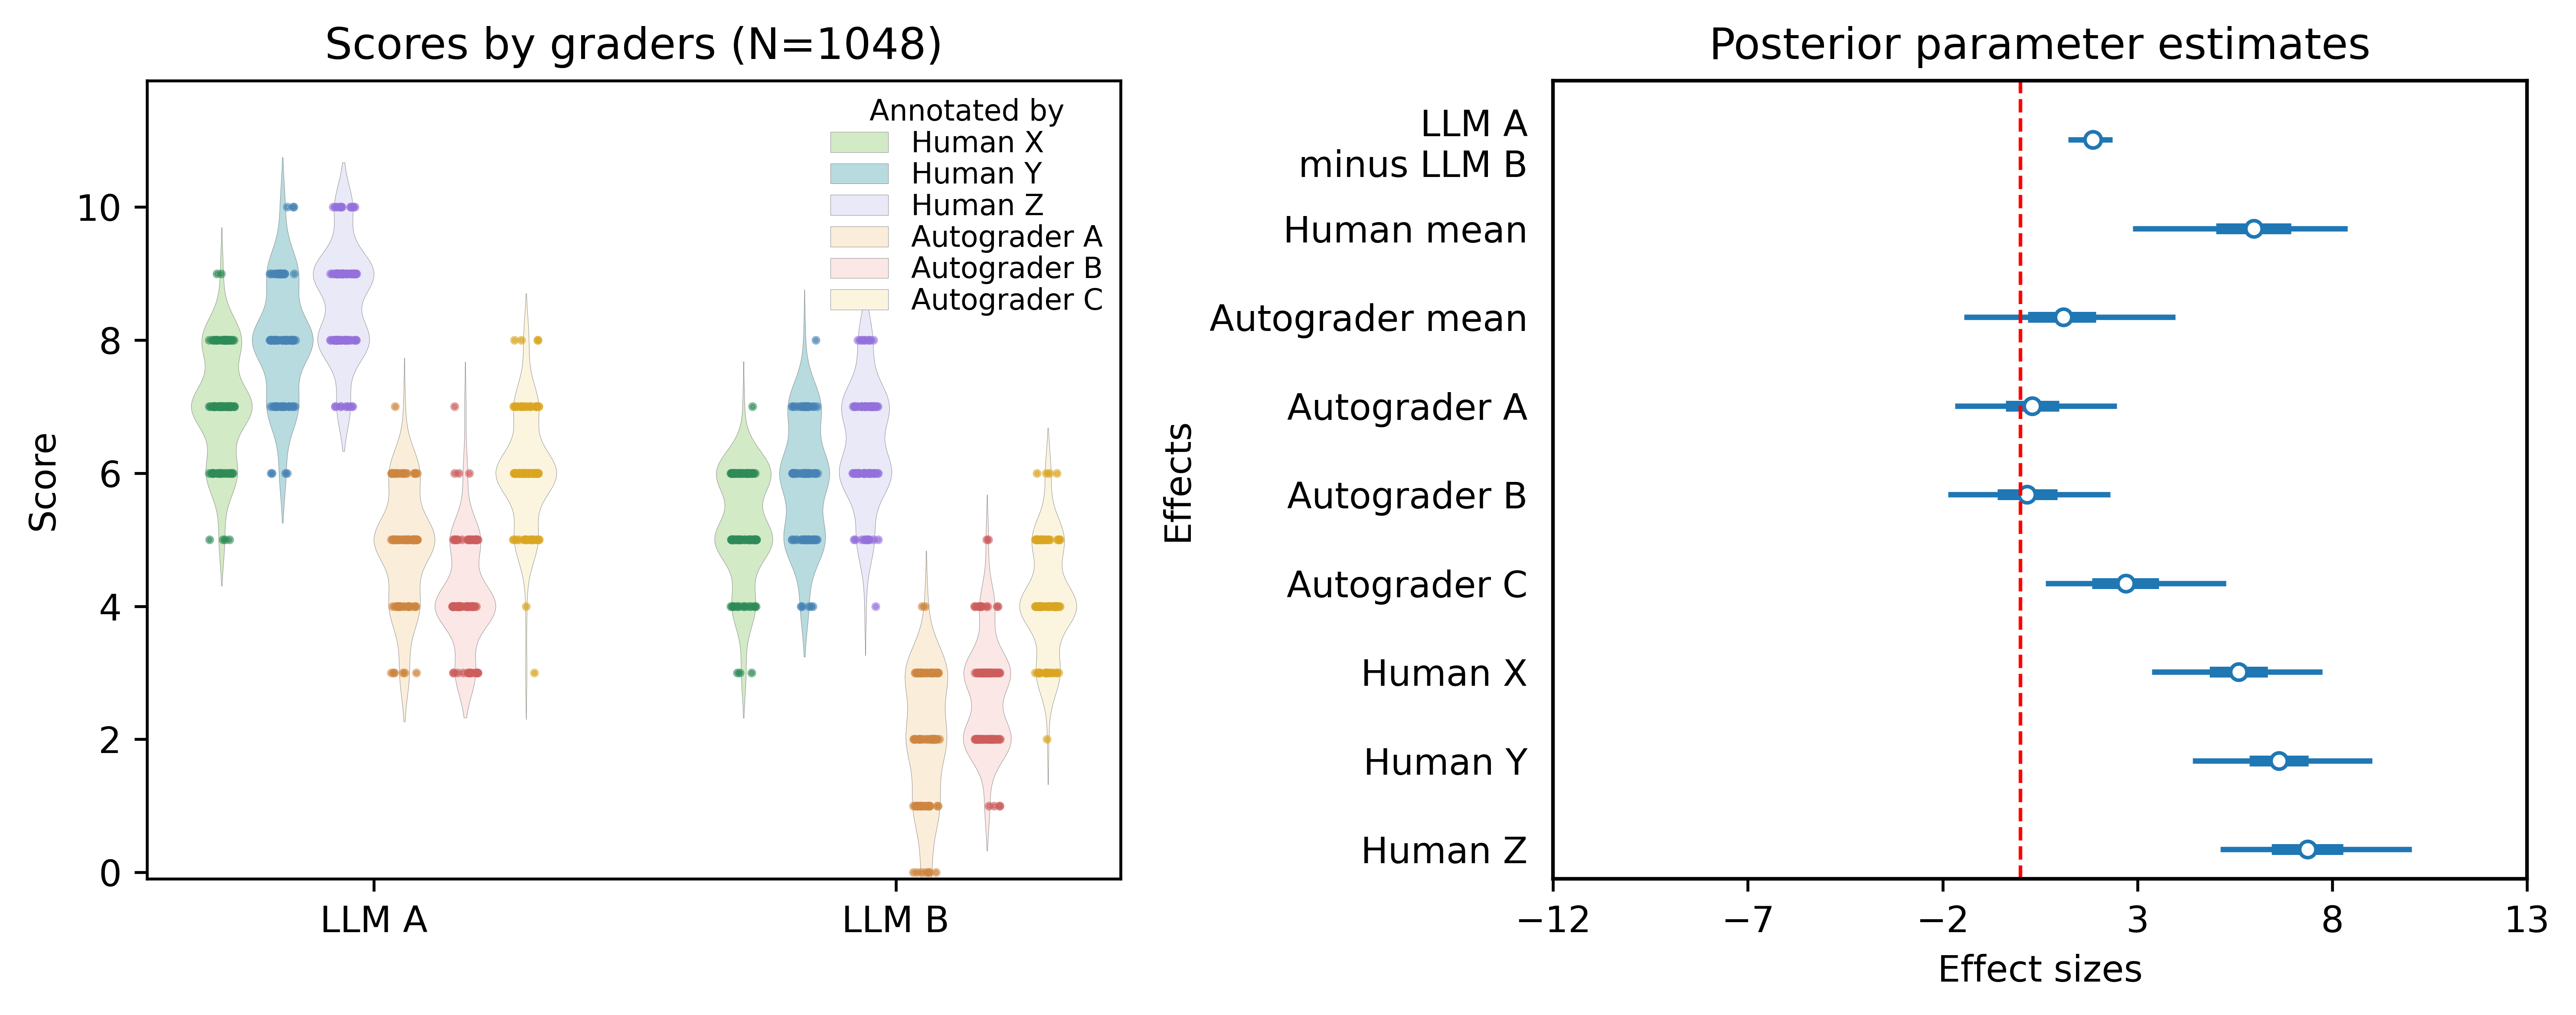

In [12]:
labeller = MapLabeller(
        var_name_map={
            "b_grader_full": "Grader",
            "b_LLM": "LLM A\nminus LLM B",  
            "b_interaction_grader_LLM_full": "Grader×LLM",
            "b_grader_type_0": "Human mean",
            "b_grader_type_1": "Autograder mean",
            "b_grader_0": "Autograder A",
            "b_grader_1": "Autograder B",
            "b_grader_2": "Autograder C",
            "b_grader_3": "Human X",
            "b_grader_4": "Human Y",
            "b_grader_5": "Human Z",
        }
    )

plot_combined_figure(
    df=df,
    idata=idata_hierarchical,
    var_names=[
        "b_LLM",
        "b_grader_type_0", "b_grader_type_1",
        "b_grader_0", "b_grader_1", "b_grader_2",
        "b_grader_3", "b_grader_4", "b_grader_5"
    ],
    labeller=labeller,
    color_scheme='multiple_graders',
    x_var='LLM',
    x_label=None,
    dodge=True,
    fig_path="../../figures/figure4.png",
    legend_title='Annotated by',
    xlim=[-12, 12],
    y_lim=[-0.1, 11.9],
    show_predictions=False,
    category_maps=category_maps,
    jitter_strength=0.05,
    legend_fontsize=8
)